In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [2]:
df = pd.read_csv("./advertising.csv")

## 1. Understanding the dataset

In [4]:
df.shape

(200, 4)

In [5]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [6]:
df.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [9]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


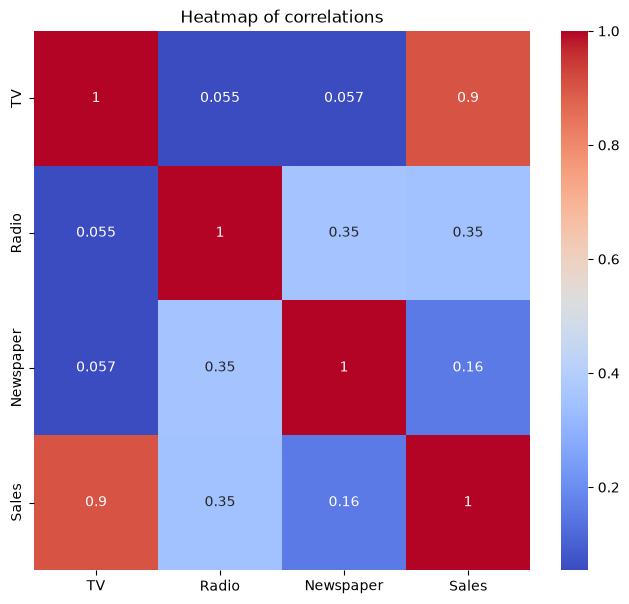

In [15]:
plt.figure(figsize=(8,7))
plt.title("Heatmap of correlations")
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

Form the above analysis the relation of tv vs sales is the strongest followed by radio and the newspaper has the least. Hence the model should be prepared from the tv vs sales relation and then try radio vs sales

## 2. Training the model

In [22]:
X1 = df[["TV"]]
Y1 = df["Sales"]

In [23]:
X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, random_state=42, test_size=0.2)

print(X1_train.shape)
print(X1_test.shape)
print(Y1_train.shape)
print(Y1_test.shape)

model = LinearRegression()

model.fit(X1_train, Y1_train)

(160, 1)
(40, 1)
(160,)
(40,)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.06]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['TV']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.007
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [25]:
print("Intercept (c): ", model.intercept_)
print("Slope (m): ", model.coef_[0])

Intercept (c):  7.007108428241848
Slope (m):  0.0554829439314632


## 3. Checking the metrics

In [26]:
y1_pred = model.predict(X1_test)

r2 = r2_score(Y1_test, y1_pred)
mae = mean_absolute_error(Y1_test, y1_pred)
mse = mean_squared_error(Y1_test, y1_pred)
rmse = root_mean_squared_error(Y1_test, y1_pred)

print("r square: ", r2)
print("mean absolute error: ", mae)
print("mean squared error: ", mse)
print("root mean squared error: ", rmse)

r square:  0.802561303423698
mean absolute error:  1.9502948931650088
mean squared error:  6.101072906773963
root mean squared error:  2.470035001123256


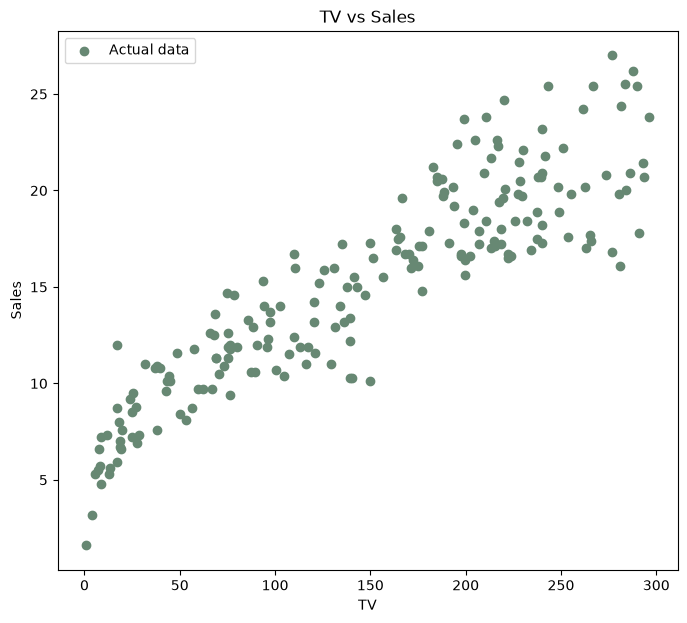

In [27]:
plt.figure(figsize=(8,7))

plt.scatter(X1, Y1, color="#678873", label="Actual data")
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.legend()
plt.show()

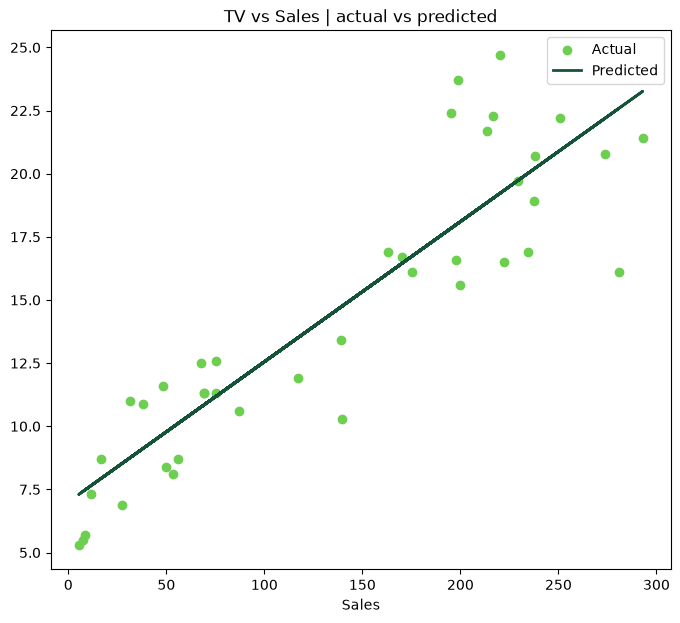

In [28]:
plt.figure(figsize=(8,7))

plt.scatter(X1_test, Y1_test, color="#6CCF50", label="Actual")
plt.plot(X1_test, y1_pred, color="#145338", label="Predicted", linewidth=2)
plt.xlabel("TV")
plt.xlabel("Sales")
plt.title("TV vs Sales | actual vs predicted")
plt.legend()
plt.show()

In [30]:
X1_full = df[["TV"]]

df["Predicted_Sales"] = model.predict(X1_full)

print(df[['TV', "Sales", "Predicted_Sales"]].head(15))

       TV  Sales  Predicted_Sales
0   230.1   22.1        19.773734
1    44.5   10.4         9.476099
2    17.2   12.0         7.961415
3   151.5   16.5        15.412774
4   180.8   17.9        17.038425
5     8.7    7.2         7.489810
6    57.5   11.8        10.197378
7   120.2   13.2        13.676158
8     8.6    4.8         7.484262
9   199.8   15.6        18.092601
10   66.1   12.6        10.674531
11  214.7   17.4        18.919296
12   23.8    9.2         8.327602
13   97.5   13.7        12.416695
14  204.1   19.0        18.331177


## Now the trial for the radio vs sale data

In [31]:
X2 = df[["Radio"]]
Y2 = df["Sales"]

In [33]:
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, random_state=42, test_size=0.2)

print(X2_train.shape)
print(X2_test.shape)
print(Y2_train.shape)
print(Y2_test.shape)

model2 = LinearRegression()

model2.fit(X2_train, Y2_train)

(160, 1)
(40, 1)
(160,)
(40,)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.12]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Radio']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.59
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [34]:
print("Intercept (c): ", model2.intercept_)
print("Slope (m): ", model2.coef_[0])

Intercept (c):  12.585523978355143
Slope (m):  0.1200011375271652


In [35]:
y2_pred = model.predict(X2_test)

r2 = r2_score(Y2_test, y2_pred)
mae = mean_absolute_error(Y2_test, y2_pred)
mse = mean_squared_error(Y2_test, y2_pred)
rmse = root_mean_squared_error(Y2_test, y2_pred)

print("r square: ", r2)
print("mean absolute error: ", mae)
print("mean squared error: ", mse)
print("root mean squared error: ", rmse)

r square:  0.10697088619553419
mean absolute error:  4.596574324841752
mean squared error:  27.595581948583174
root mean squared error:  5.253149716939655


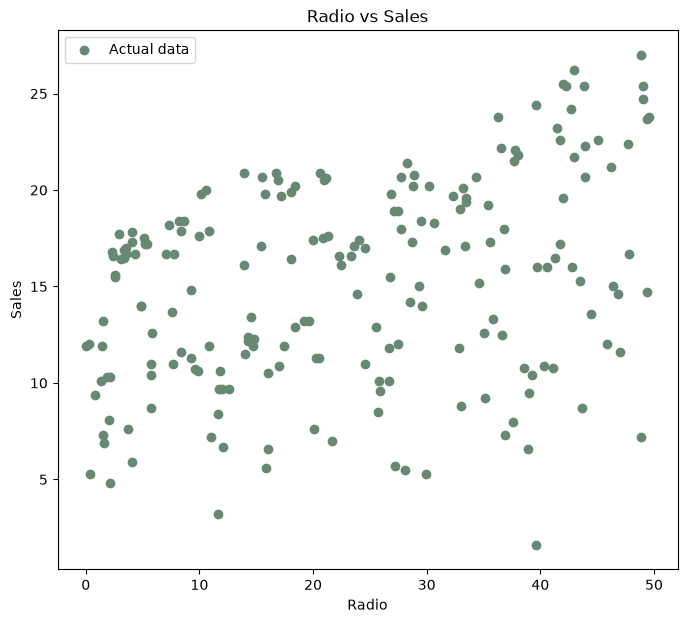

In [36]:
plt.figure(figsize=(8,7))

plt.scatter(X2, Y2, color="#678873", label="Actual data")
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.legend()
plt.show()

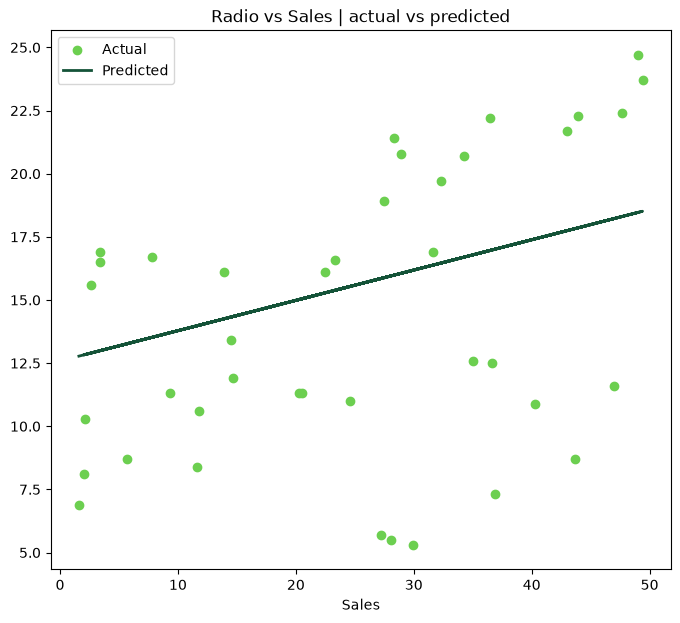

In [37]:
plt.figure(figsize=(8,7))

plt.scatter(X2_test, Y2_test, color="#6CCF50", label="Actual")
plt.plot(X2_test, y2_pred, color="#145338", label="Predicted", linewidth=2)
plt.xlabel("Radio")
plt.xlabel("Sales")
plt.title("Radio vs Sales | actual vs predicted")
plt.legend()
plt.show()

In [40]:
X2_full = df[["Radio"]]

df["Predicted_Sales"] = model.predict(X2_full)

print(df[['Radio', "Sales", "Predicted_Sales"]].head(15))

    Radio  Sales  Predicted_Sales
0    37.8   22.1        17.121567
1    39.3   10.4        17.301569
2    45.9   12.0        18.093576
3    41.3   16.5        17.541571
4    10.8   17.9        13.881536
5    48.9    7.2        18.453580
6    32.8   11.8        16.521561
7    19.6   13.2        14.937546
8     2.1    4.8        12.837526
9     2.6   15.6        12.897527
10    5.8   12.6        13.281531
11   24.0   17.4        15.465551
12   35.1    9.2        16.797564
13    7.6   13.7        13.497533
14   32.9   19.0        16.533561
